In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

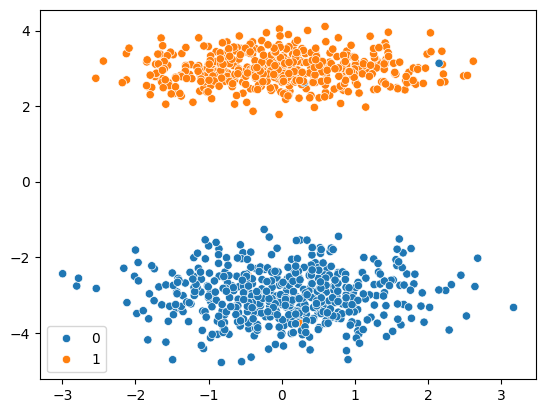

In [2]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, class_sep=3, random_state=0)
sns.scatterplot(x=X[:, 0], y = X[:, 1], hue=y)
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((700, 2), (300, 2), (700,), (300,))

### Logistic Regression using Perceptron Method

In [5]:
class Logistic_Regression_using_Perceptron:

    def __init__(self, epochs: int = 1000, learning_rate:float = 0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None

    def __step(self ,i:float) -> int:
        return 1 if i>=0 else 0
    
    def fit(self, X: np.ndarray | pd.DataFrame, y: np.ndarray):

        X = np.insert(X, 0, 1, axis=1)
        weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0, X.shape[0])
            y_pred = self.__step(np.dot(X[idx], weights))
            weights += self.learning_rate * (y[idx] - y_pred)* X[idx]

        self.coef_ = weights[1:]
        self.intercept_ = weights[0]
    
    def predict(self, X_test: np.ndarray | pd.DataFrame) -> np.ndarray:
        return np.where((np.dot(X_test, self.coef_) + self.intercept_) >= 0, 1, 0)

### Logistic Rergession Using Sigmoid Fucntion

In [6]:
class Logistic_Regression_using_Sigmoid_Function:

    def __init__(self, epochs: int = 1000, learning_rate:float = 0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None

    def __sigmoid(self, z: float) -> float:
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X: np.ndarray | pd.DataFrame, y: np.ndarray):

        X = np.insert(X, 0, 1, axis=1)
        weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0, X.shape[0])
            y_pred = self.__sigmoid(np.dot(X[idx], weights))
            weights += self.learning_rate * (y[idx] - y_pred)* X[idx]

        self.coef_ = weights[1:]
        self.intercept_ = weights[0]
    
    def predict(self, X_test: np.ndarray | pd.DataFrame) -> np.ndarray:
        return np.where((np.dot(X_test, self.coef_) + self.intercept_) >= 0, 1, 0)

### Logistic Regression Using Gradient Descent with Log-Loss error as Loss Function 

In [ ]:
class Logistic_Regression_GD:

    def __init__(self, epochs, learning_rate):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.coef_ = None
        self.intercept_ = None

    def __sigmoid(self, z : float) -> float:
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X : np.ndarray | pd.DateOffset, y: np.ndarray):

        X = np.insert(X, 0, 1, axis = 1)
        weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            y_pred = self.__sigmoid(np.dot(X, weights))

            weights = weights + self.learning_rate * (np.dot((y - y_pred), X)) / X.shape[0]
        
        self.coef_ = weights[1:]
        self.intercept_ = weights[0]

    def predict(self, X: np.ndarray | pd.DataFrame) -> np.ndarray:
         return np.where((np.dot(X,self.coef_) + self.intercept_) >= 0, 1, 0)

In [91]:
clf = Logistic_Regression_using_Perceptron(1000, 0.5)

clf.fit(X_train, y_train)

print(f"Coefficient : {clf.coef_} || Intercept : {clf.intercept_}")

print(accuracy_score(y_test, clf.predict(X_test)))

Coefficient : [0.15678746 2.03569543] || Intercept : 1.0
0.9966666666666667


In [92]:
clf2 = Logistic_Regression_using_Sigmoid_Function(1000, 0.5)

clf2.fit(X_train, y_train)

print(f"Coefficient : {clf2.coef_} || Intercept : {clf2.intercept_}")

print(accuracy_score(y_test, clf2.predict(X_test)))

Coefficient : [-0.32942838  2.66085635] || Intercept : 0.18139258400830557
0.9966666666666667


In [93]:
clf3 = Logistic_Regression_GD(1000, 0.5)

clf3.fit(X_train, y_train)

print(f"Coefficient : {clf3.coef_} || Intercept : {clf3.intercept_}")

print(accuracy_score(y_test, clf3.predict(X_test)))

Coefficient : [-0.60446863  1.97951691] || Intercept : 0.09664169986227349
0.9966666666666667


In [94]:
org_log = LogisticRegression(solver='sag')

org_log.fit(X_train, y_train)

print(f"Coefficient : {org_log.coef_} || Intercept : {org_log.intercept_}")

print(accuracy_score(y_test, org_log.predict(X_test)))

Coefficient : [[-0.49319698  1.88448717]] || Intercept : [0.0214843]
0.9966666666666667


In [95]:
m1 = -(clf.coef_[0] / clf.coef_[1])
b1 = -(clf.intercept_ / clf.coef_[1])

m2 = -(clf2.coef_[0] / clf2.coef_[1])
b2 = -(clf2.intercept_ / clf2.coef_[1])

m3 = -(clf3.coef_[0] / clf3.coef_[1])
b3 = -(clf3.intercept_ / clf3.coef_[1])

m_org = -(org_log.coef_[0, 0] / org_log.coef_[0, 1])
b_org = -(org_log.intercept_ / org_log.coef_[0, 1])

In [96]:
x = np.linspace(-3.5, 3.5, 100)

y1 = m1*x + b1

y2 = m2*x + b2

y3 = m3*x + b3

y_org = m_org * x + b_org

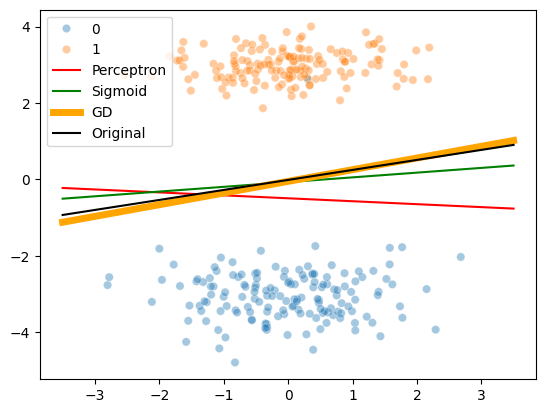

In [97]:
sns.scatterplot(x=X_test[:, 0], y = X_test[:, 1], hue=y_test, alpha = 0.4)
sns.lineplot(x = x, y = y1, label = "Perceptron", color = 'red')
sns.lineplot(x = x, y = y2, label = "Sigmoid", color = 'green')
sns.lineplot(x = x, y = y3, label = "GD", color = 'orange', linewidth = 5)
sns.lineplot(x = x, y = y_org, label = "Original", color = 'Black')
plt.legend()
plt.show()

### As we can see the Our Regressions's Line is mostly Overlapping the Sklearn's LogisticRegression